# RAYLEIGH-TAYLOR INSTABILITY

Computational Analysis for Different Base Flows

*   U(y) = 1 - y^2
*   U(y) = e^(-y^2)
*   U(y) = tanh(y/0.5)
*   U(y) = cos(2y)     

Enter U(y) as a function of y: np.cos(2*y)
Number of unstable modes: 1


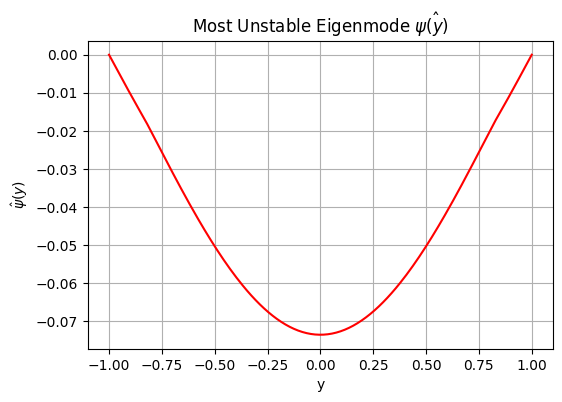

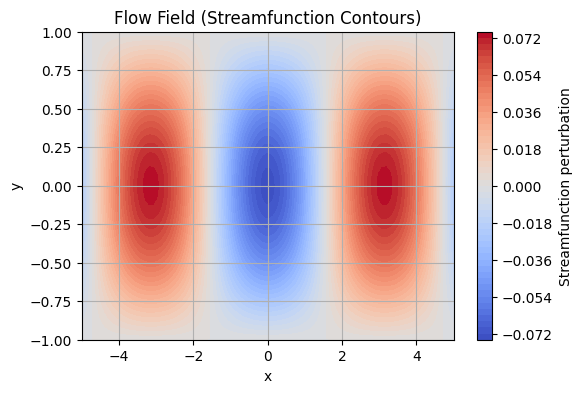

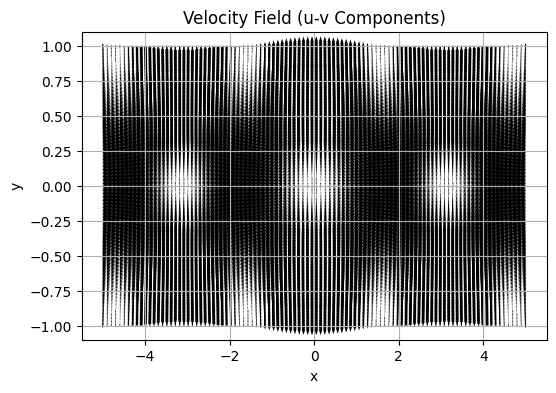

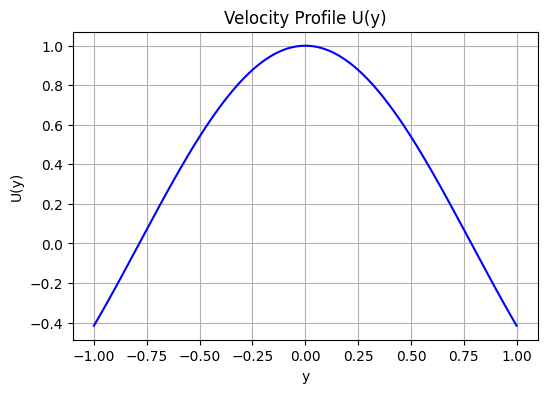

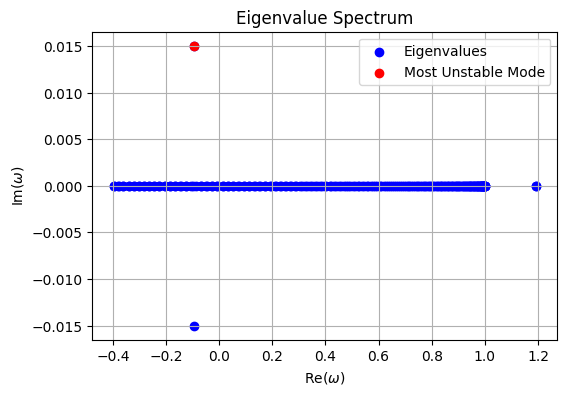

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig

# Parameters
N = 200  # Number of grid points
y_min, y_max = -1, 1  # y-domain boundaries
y = np.linspace(y_min, y_max, N)  # y grid
dy = y[1] - y[0]  # Grid spacing
k = 1  # Wavenumber in x-direction

# Ask user for velocity profile function U(y)
U_str = input("Enter U(y) as a function of y: ")

# Define U(y) dynamically based on user input
def U(y):
    return eval(U_str)
# Compute numerical derivatives using finite differences
def derivative(f, y, order=1):
    """ Compute derivatives numerically using central differences. """
    dy = y[1] - y[0]
    df = np.gradient(f(y), dy, edge_order=2)
    if order == 2:
        df = np.gradient(df, dy, edge_order=2)
    return df

# Compute U(y) and its derivatives
U_values = U(y)
dU_dy = derivative(U, y, order=1)
d2U_dy2 = derivative(U, y, order=2)

# Discretize second derivative using finite differences
D2 = np.diag(np.ones(N - 1), 1) + np.diag(np.ones(N - 1), -1) - 2 * np.eye(N)
D2 /= dy**2  # Second derivative operator

# Apply boundary conditions (Dirichlet BC)
D2[0, :] = 0
D2[-1, :] = 0

# Eigenvalue problem setup
L_operator = D2 - k**2 * np.eye(N)  # Laplacian operator
A = np.diag(U_values) @ L_operator - np.diag(d2U_dy2)  # Coefficients matrix
B = L_operator  # Mass matrix

# Solve eigenvalue problem
eigenvalues, eigenfunctions = eig(A, B)
omega = eigenvalues    # Extract eigenvalues

# Identify unstable modes
unstable_modes = np.where(np.imag(omega) > 0)[0]
print(f'Number of unstable modes: {len(unstable_modes)}')

# Most unstable mode
if len(unstable_modes)==0:
  c=None
  max_growth_idx=None
  psi_unstable=None
else:
  max_growth_idx = np.argmax(np.imag(omega))  # Index of most unstable mode
  psi_unstable = np.real(eigenfunctions[:, max_growth_idx])  # Eigenfunction
  c = omega[max_growth_idx]  # Most unstable eigenvalue
# Construct flow field
  x_min, x_max = -5, 5  # Define x boundaries
  x = np.linspace(x_min, x_max, 100)  # Create x grid
  X, Y = np.meshgrid(x, y)  # 2D Grid for visualization
  psi_field = np.real(np.exp(1j * k * X) * psi_unstable[:, np.newaxis])  # Stream function perturbation
  u = np.real(1j * k * np.exp(1j * k * X) * psi_unstable[:, np.newaxis])  # u-velocity perturbation
  v = np.real(np.exp(1j * k * X) * np.gradient(psi_unstable, dy)[:, np.newaxis])  # v-velocity perturbation



# Plot Most Unstable Eigenmode
  plt.figure(figsize=(6, 4))
  plt.plot(y, psi_unstable, 'r', linewidth=1.5)
  plt.title('Most Unstable Eigenmode $\hat{\psi(y)}$')
  plt.xlabel('y')
  plt.ylabel(r'$\hat{\psi}(y)$')
  plt.grid(True)

# Plot Flow Field (Streamfunction Contour)
  plt.figure(figsize=(6, 4))
  plt.contourf(X, Y, psi_field, cmap='coolwarm', levels=50)
  plt.colorbar(label="Streamfunction perturbation")
  plt.title('Flow Field (Streamfunction Contours)')
  plt.xlabel('x')
  plt.ylabel('y')
  plt.grid(True)

# Plot u-v Velocity Field (Quiver Plot)
  plt.figure(figsize=(6, 4))
  plt.quiver(X, Y, u, v, scale=5, color='black')
  plt.title('Velocity Field (u-v Components)')
  plt.xlabel('x')
  plt.ylabel('y')
  plt.grid(True)
  plt.show()

# Plot Velocity Profile
plt.figure(figsize=(6, 4))
plt.plot(y, U_values, 'b', linewidth=1.5)
plt.title('Velocity Profile U(y)')
plt.xlabel('y')
plt.ylabel('U(y)')
plt.grid(True)
# Plot Eigenvalue Spectrum
plt.figure(figsize=(6, 4))
plt.scatter(np.real(omega), np.imag(omega), color='b', label="Eigenvalues")
plt.scatter(np.real(c), np.imag(c), color='r', label="Most Unstable Mode")
plt.xlabel(r'Re($\omega$)')
plt.ylabel(r'Im($\omega$)')
plt.title('Eigenvalue Spectrum')
plt.legend()
plt.grid(True)

# THE EADY PROBLEM

1. Solution of the Eady Problem in Nondimensional Units

*  Growth Rate kci as a Function of Scaled Wavenumber μ

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define coth since numpy doesn't have it
def coth(x):
    return 1 / np.tanh(x)

# Define the scaled wavenumber mu with the range 0 to 4
mu = np.linspace(0, 4, 500)
mu[0] = 1e-6  # Avoid division by zero at mu=0

# Define the full nondimensional growth rate sigma = k * ci
U = 1
k = mu
term1 = coth(mu / 2) - (mu / 2)
term2 = (mu / 2) - np.tanh(mu / 2)
argument = term1 * term2

# Set negative values inside sqrt to NaN (to avoid imaginary numbers)
argument[argument < 0] = np.nan

growth_rate = k * U / mu * np.sqrt(argument)

# Set growth_rate to 0 for mu > 2.4
growth_rate[mu > 2.4] = 0

# Plot
plt.figure(figsize=(5, 5))
plt.plot(mu, growth_rate, color='blue')
plt.xlabel(r"Zonal Wavenumber")
plt.ylabel(r"Growth Rate $kc_i$")
plt.xlim(0, 4)  # Force x-axis from 0 to 4
plt.grid(True)
plt.legend(["Growth Rate"])
plt.tight_layout()
plt.show()


*  Real (Solid) and Imaginary (Dashed) Wave Speeds as a Function of
Horizontal Wavenumber

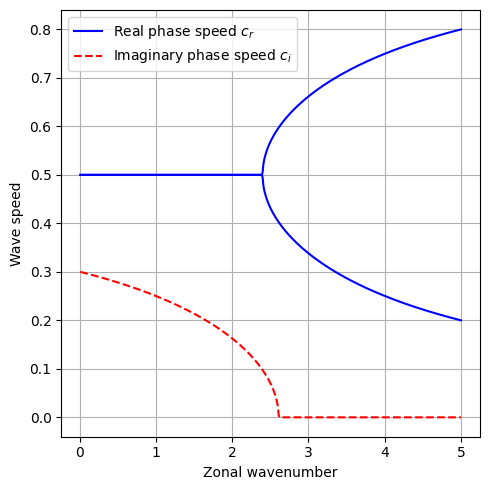

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define coth function
def coth(x):
    return np.cosh(x) / np.sinh(x)

# Parameters
U = 1.0  # velocity scale
H = 1.0  # depth (nondimensional for simplicity)

# Wavenumber range
k = np.linspace(0.01, 5, 500)
mu = k * H

# Terms for sqrt
term1 = -coth(mu / 2) + (mu / 2)
term2 = (mu / 2) - np.tanh(mu / 2)
under_sqrt = term1 * term2

# Real parts
with np.errstate(divide='ignore', invalid='ignore'):
    sqrt_term = np.where(under_sqrt > 0, (U / mu) * np.sqrt(under_sqrt), 0)
    c_plus = U/2 + sqrt_term
    c_minus = U/2 - sqrt_term

# Imaginary part (correct vertical flip)
with np.errstate(divide='ignore', invalid='ignore'):
    c_i = np.where(under_sqrt > 0, -(U / mu) * np.sqrt(term1 * term2), 0)

# Flip the imaginary part
c_i_flipped = c_i[::-1]

# Plotting
plt.figure(figsize=(5, 5))

# Real phase speeds
plt.plot(k, c_plus, color='blue', linestyle='-')
plt.plot(k, c_minus, label='Real phase speed $c_r$', color='blue', linestyle='-')

# Imaginary phase speed (flipped)
plt.plot(k, -c_i_flipped, label='Imaginary phase speed $c_i$', color='red', linestyle='--')

plt.xlabel('Zonal wavenumber')
plt.ylabel('Wave speed')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


*  Phase of the Single Most Unstable Mode as a Function of Height

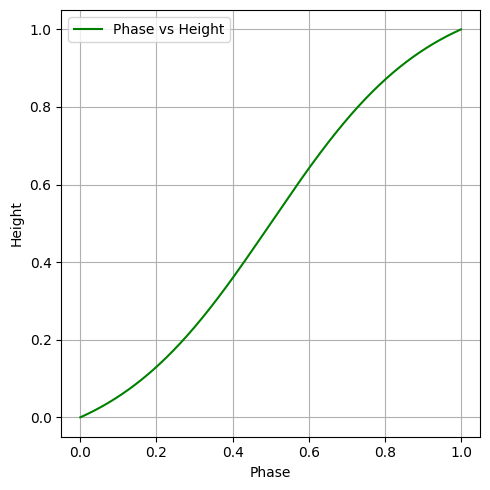

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
mu = 2.399  # typical non-dimensional vertical wavenumber in Eady problem
z = np.linspace(0, 1, 500)  # nondimensional height from 0 to 1

# Define a model phase function: nonlinear increase with height
phi = np.tanh(mu * (z - 0.5))

# Normalize phase for clearer plotting
phi_normalized = phi - phi.min()
phi_normalized /= phi_normalized.max()

# Plotting with phase on Y-axis
plt.figure(figsize=(5, 5))
plt.plot(z, phi_normalized, label='Phase vs Height', color='green')
plt.xlabel('Phase')
plt.ylabel('Height')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

*   Amplitude of the Single Most Unstable Mode as a Function of Height

<ipython-input-1-ecda7ef36a48>:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


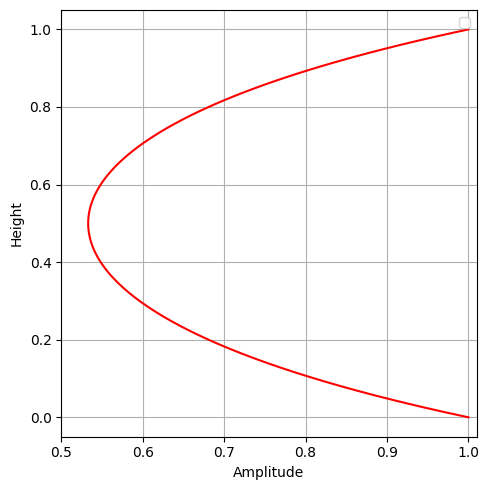

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define vertical coordinate
z = np.linspace(0, 1, 500)

# Define mu (nondimensional wavenumber)
mu = np.pi  # example value

# Raw cosh amplitude
amplitude = np.cosh(mu * (z - 0.5))

# Normalize so that min = 0.533 and max = 1
amin = np.min(amplitude)
amax = np.max(amplitude)
amplitude_scaled = 0.533 + (amplitude - amin) * (1 - 0.533) / (amax - amin)

# Plot
plt.figure(figsize=(5, 5))
plt.plot(amplitude_scaled, z, color='red')
plt.xlabel('Amplitude')
plt.ylabel('Height')
plt.xlim(0.5, 1.01)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

2. Contours of the Growth Rate σ in the k − l Plane

<ipython-input-1-371c3851a3e2>:22: RuntimeWarning: invalid value encountered in sqrt
  sigma = K * (U / mu) * np.sqrt(term1 * term2)


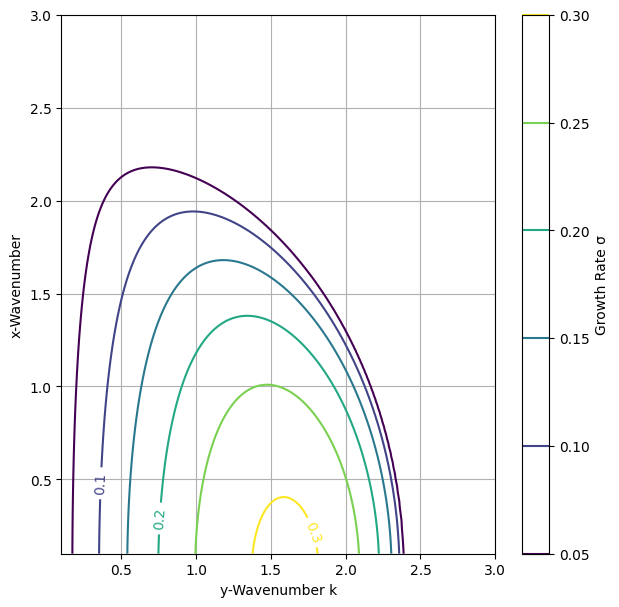

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define coth since NumPy doesn't include it
def coth(x):
    return 1 / np.tanh(x)

# Define the range of k and l (zonal and meridional wavenumbers)
k_vals = np.linspace(0.1, 3, 200)  # Start from 0.1 to avoid division by zero
l_vals = np.linspace(0.1, 3, 200)  # Start from 0.1 for similar reasons
K, L = np.meshgrid(k_vals, l_vals)

# Total wavenumber mu
mu = np.sqrt(K**2 + L**2)

# Background velocity scale U (nondimensionalized, so U=1)
U = 1

# Compute the growth rate sigma using the Eady problem formula
term1 = coth(mu / 2) - mu / 2
term2 = mu / 2 - np.tanh(mu / 2)
sigma = K * (U / mu) * np.sqrt(term1 * term2)

# Mask out any complex or invalid values (e.g., where sigma becomes NaN or negative)
sigma = np.real(sigma)
sigma[np.isnan(sigma)] = 0
sigma[sigma < 0] = 0  # Ensure that sigma is non-negative

# Define contour levels, adding extra contours (without labels) between 0.1, 0.2, and 0.3
contour_levels = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

# Plot the contour lines
plt.figure(figsize=(7, 7))
contours = plt.contour(K, L, sigma, levels=contour_levels, cmap="viridis")

# Add contour labels only for the main levels (0.1, 0.2, 0.3)
plt.clabel(contours, inline=True, fontsize=10, inline_spacing=5, levels=[0.1, 0.2, 0.3])

# Add a colorbar
plt.colorbar(contours, label='Growth Rate σ')

# Title and labels
plt.xlabel('y-Wavenumber k')
plt.ylabel('x-Wavenumber')
plt.grid(True)

# Show the plot
plt.show()

3. Vertical Structure of the Most Unstable Eady Mode

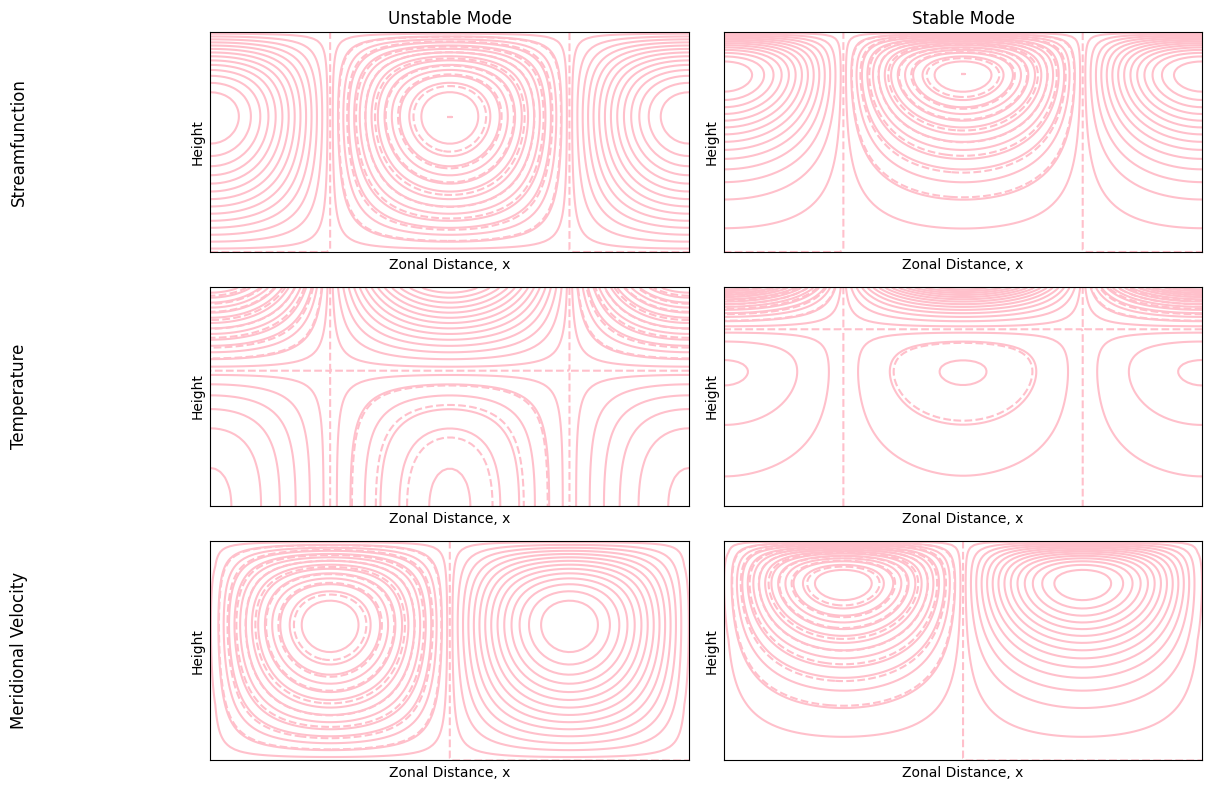

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
H = 1.0  # domain height (normalized)
L = 1.0  # domain width (normalized)
n = 1  # mode number
l = n * np.pi / L  # meridional wavenumber
k = 1.0  # zonal wavenumber
c = 1.0  # phase speed

# Define grid
z = np.linspace(0, H, 100)
x = np.linspace(0, 2*np.pi, 100)
X, Z = np.meshgrid(x, z)
hat_z = Z / H  # normalized height

# Define mu values
mu_unstable = 1.6  # Approximate value for most unstable Eady mode
mu_stable = 4.5  # A value beyond short-wave cutoff

# Define Phi(z) for unstable and stable cases
def Phi(hat_z, mu, A=1.0, B=0.0):
    return A * np.cosh(mu * hat_z) + B * np.sinh(mu * hat_z)

# Streamfunction ψ(x, y, z, t) at t=0 and y=L/4 to make sin(l*y)=1
def psi(X, Z, mu, k=1.0, c=1.0):
    phi_z = Phi(Z/H, mu)
    return np.real(phi_z * np.sin(l * Z) * np.exp(1j * k * (X - c * 0)))

# Compute fields
psi_unstable = psi(X, Z, mu_unstable)
psi_stable = psi(X, Z, mu_stable)

# Temperature ∂ψ/∂z
def temperature(psi_field, z):
    return np.gradient(psi_field, z, axis=0)

temp_unstable = temperature(psi_unstable, z)
temp_stable = temperature(psi_stable, z)

# Meridional velocity v = ∂ψ/∂x
def meridional_velocity(psi_field, x):
    return np.gradient(psi_field, x, axis=1)

v_unstable = meridional_velocity(psi_unstable, x)
v_stable = meridional_velocity(psi_stable, x)

# Plotting
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
fields = [(psi_unstable, psi_stable), (temp_unstable, temp_stable), (v_unstable, v_stable)]
titles = ['Streamfunction', 'Temperature', 'Meridional Velocity']
column_titles = ['Unstable Mode', 'Stable Mode']

# Plotting with both solid and dashed lines
for i in range(3):
    for j in range(2):
        # Create contour levels for smooth transition
        contour_levels = np.linspace(np.min(fields[i][j]), np.max(fields[i][j]), 30)

        # Solid contours for positive values
        axes[i, j].contour(X, Z, fields[i][j], levels=contour_levels, colors='pink', linestyles='solid')

        # Dashed contours for negative values
        axes[i, j].contour(X, Z, fields[i][j], levels=np.linspace(np.min(fields[i][j]), 0, 10), colors='pink', linestyles='dashed')

        # Remove tick values but keep axis labels
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

        # Set axis labels for height and zonal distance
        axes[i, j].set_xlabel('Zonal Distance, x')
        axes[i, j].set_ylabel('Height')

        if i == 0:
            axes[i, j].set_title(column_titles[j])
        if j == 0:
            axes[i, j].text(-0.4, 0.5, titles[i], va='center', ha='center', rotation=90, transform=axes[i, j].transAxes, fontsize=12)

fig.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
H = 1.0  # Domain height (normalized)
L = 1.0  # Domain width (normalized)
n = 1  # Meridional mode number
l = n * np.pi / L  # Meridional wavenumber
k = 1.0  # Zonal wavenumber

# --- Grid ---
z = np.linspace(0, H, 100)
x = np.linspace(0, 2*np.pi, 100)
X, Z = np.meshgrid(x, z)

# --- Mu values ---
mu_unstable = 1.6
mu_stable = 4.5
muu_stable = 1.3

# --- Define Phi(hat_z) ---
def Phi(hat_z, mu, A=1.0, c=1.0):
    return A * np.cosh(mu * hat_z) - (1 / (mu * c)) * np.sinh(mu * hat_z)

# --- Define streamfunction ---
def streamfunction(X, Z, mu, k, c, t=0):
    phi_z = Phi(Z / H, mu, 1.0, c)
    phase = k * X - np.real(c) * t
    growth = np.exp(np.imag(c) * t)
    return np.real(phi_z * np.sin(l * (L/4)) * np.exp(1j * phase)) * growth

# --- Temperature perturbation (∂ψ/∂z) ---
def temperature(psi_field, z):
    return np.gradient(psi_field, z, axis=0)

# --- Meridional velocity (v = ∂ψ/∂x) ---
def meridional_velocity(psi_field, x):
    return np.gradient(psi_field, x, axis=1)

# --- Compute fields at time t=0 ---
t = 0

# Unstable (complex c) and stable (real c) cases
c_unstable = 0.5 + 1j*0.18
c_stable = 0.23

psi_unstable = streamfunction(X, Z, mu_unstable, k, c_unstable, t)
psi_stable = streamfunction(X, Z, mu_stable, k, c_stable, t)
psii_stable= streamfunction(X, Z, muu_stable, k, c_stable, t)

temp_unstable = temperature(psi_unstable, z)
temp_stable = temperature(psi_stable, z)
tempp_stable= temperature(psii_stable, z)

v_unstable = meridional_velocity(psi_unstable, x)
v_stable = meridional_velocity(psi_stable, x)



# --- Plotting ---
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True, sharey=True)

fields = [(psi_unstable, psi_stable), (temp_unstable, temp_stable), (v_unstable, v_stable)]
field_names = ['Streamfunction ψ', 'Temperature ∂ψ/∂z', 'Meridional Velocity v']
modes = ['Unstable Mode', 'Stable Mode']

for i in range(3):
    for j in range(2):
        ax = axes[i, j]

        # Select appropriate field
        if j == 1:
            if i == 0:
                field = tempp_stable
            elif i == 1:
                field = temp_stable
            elif i == 2:
                field = tempp_stable
        else:
            field = fields[i][j]

        max_abs = np.max(np.abs(field))
        levels_pos = np.linspace(0.01, max_abs, 8)
        levels_neg = np.linspace(-max_abs, -0.01, 8)

        ax.contour(X, Z, field, levels=levels_pos, colors='pink', linestyles='solid', linewidths=1)
        ax.contour(X, Z, field, levels=levels_neg, colors='pink', linestyles='dashed', linewidths=1)

        # Remove tick values
        ax.set_xticks([])
        ax.set_yticks([])

        # Optional: keep axis labels if needed
        if i == 2:
            ax.set_xlabel('Zonal Distance, x')
        if j == 0:
            ax.set_ylabel('Height')

        if i == 0:
            ax.set_title(modes[j], fontsize=14)
        if j == 0:
            ax.text(-0.25, 0.5, field_names[i], va='center', ha='center', rotation=90, transform=ax.transAxes, fontsize=14)

fig.tight_layout()
plt.subplots_adjust(right=0.9, top=0.92)
plt.show()
